In [21]:
import numpy as np
import sys
import os
import torch

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa
from utils.bam import MultiBAMv4

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [22]:
sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
second_layer = 1024
third_layer = 64

## HOW TO LOAD WEIGHT
layers = [input_col * input_row, second_layer, third_layer] # <-- must match training

multi_bam = MultiBAMv4(layers_dims=layers, eta=1e-5)

for i, bam in enumerate(multi_bam.bams):
    w_np = np.load(f"weight_{input_row*input_col}_{second_layer}_{third_layer}/weights_layer_{i}.npy")
    bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
    print(f"Loaded layer {i}: shape {bam.W.shape}")


Loaded layer 0: shape torch.Size([1024, 16896])
Loaded layer 1: shape torch.Size([64, 1024])


seed :  438
torch.Size([512, 33])
[[-1.7267692  -0.03452492  0.30971104  1.1072412  -2.3053358   5.806434
   0.07529496 -2.7206922  -3.8008442   1.8083135   1.8300405   2.0856774
  -1.7822016   0.94218475 -0.93167496 -2.178105    1.0026207   2.5858853
   1.7208083  -2.1717396   3.3530087   4.2294297  -1.5338511   1.7034736
  -0.6712152   0.19987825 -0.6854835   7.1788826  -4.9605074   1.3091033
  -1.5637381  -2.44062     2.2015338   0.11590722 -2.0759313   1.7601998
  -3.058188   -0.37080914 -4.3522196  -1.6975667  -0.8278542   0.37737548
  -1.0973977   2.7372415  -2.8948383  -3.190366    1.0412371   5.3069725
   0.6194719   3.6954784  -1.2635303  -3.586183   -4.344864   -0.49830395
   0.3140825   0.06902587 -2.5255635   5.9882784  -1.4096216  -0.7512199
   1.1409271  -3.9787676  -0.40001595  2.734629  ]]


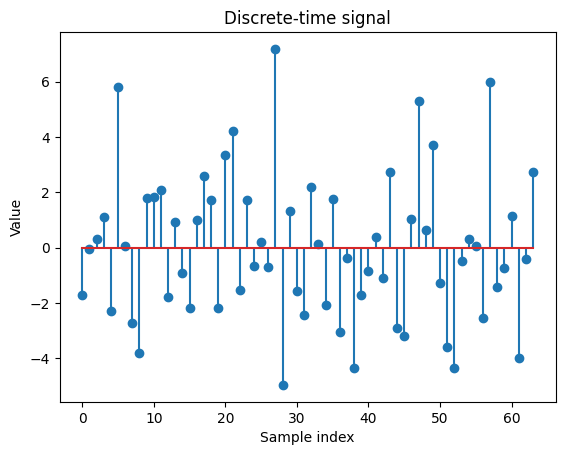

(512, 33)


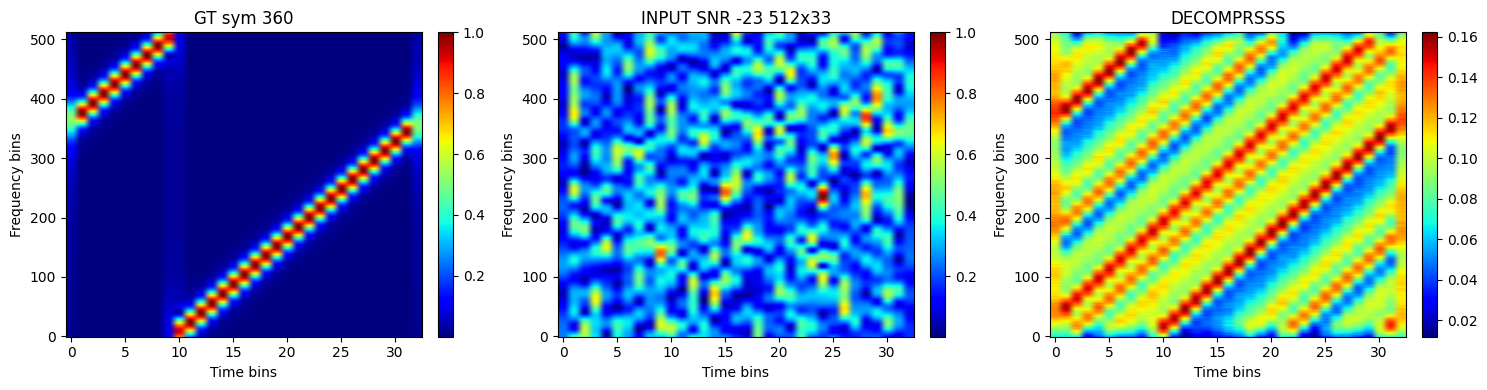

RMSE :  0.22528530775620764
RMPE :  0.050753469890809186
RMSE - to signal max ratio = 138.894 %
RMSE - to signal mean ratio = 237.247 %
Error Vector Magnitude = 0.738 => 73.815 %
RMSE :  0.198531079948888
RMPE :  0.03941458970567176
RMSE - to signal max ratio = 122.399 %
RMSE - to signal mean ratio = 209.072 %
Error Vector Magnitude = 0.911 => 91.136 %


np.float64(0.198531079948888)

In [ ]:
symbol1 = 360
# EXAMPLE OF COMPRESS and DECOMPRESS
random_ = np.random.randint(1, 999)  # integer from 1 to 10 (inclusive)
print("seed : ",random_)
seed = random_
x1 = lora_init.gen_symbol_fs(symbol1, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6

original_pisan = create_spectrogram_from_torch(x1,sf,bw,fs,input_row,input_col,0,0,1,None)

snr = -21
x = lora_init.awgn_iq_with_seed(x1,snr,seed)

input_spec = create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,0,0,1,None)
#### STEP 3 FLATTEN INPUT ########
print(input_spec.shape)
flat = input_spec.flatten().reshape(1, -1) # BEFORE COMPRESS MUST 

out1 = multi_bam.compress(flat)
print(out1)
import matplotlib.pyplot as plt

a = out1.squeeze()  
plt.figure()
plt.stem(a)
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.title("Discrete-time signal")
plt.show()

out2 = multi_bam.decompress(out1)

#### STEP 4 AFTER DECOMPRESS RESHAPE to INITIAL SHAPE ########
reco_flat = out2.reshape(-1)  # AFTER DECOMPRESS MUST
reco_spec = reco_flat.reshape(input_row, input_col)
print(reco_spec.shape)

array_a = [original_pisan,input_spec,reco_spec]

show_multiple_spectrograms(array_a,[f'GT sym {symbol1}',f"INPUT SNR {snr} {input_row}x{input_col}","DECOMPRSSS"],3)
check_simmilarity(reco_spec,input_spec)
check_simmilarity(reco_spec,original_pisan)

In [24]:
sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
second_layer = 1024
third_layer = 32

## HOW TO LOAD WEIGHT
layers = [input_col * input_row, second_layer, third_layer] # <-- must match training

multi_bam2 = MultiBAMv4(layers_dims=layers, eta=1e-5)

for i, bam in enumerate(multi_bam2.bams):
    w_np = np.load(f"weight_{input_row*input_col}_{second_layer}_{third_layer}/weights_layer_{i}.npy")
    bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
    print(f"Loaded layer {i}: shape {bam.W.shape}")


symbol1 = 320
# EXAMPLE OF COMPRESS and DECOMPRESS
seed = seed
x1 = lora_init.gen_symbol_fs(symbol1, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6

original_pisan = create_spectrogram_from_torch(x1,sf,bw,fs,input_row,input_col,0,0,1,None)

snr = -22
x = lora_init.awgn_iq_with_seed(x1,snr,seed)

input_spec = create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,0,0,1,None)
#### STEP 3 FLATTEN INPUT ########
print(input_spec.shape)
flat = input_spec.flatten().reshape(1, -1) # BEFORE COMPRESS MUST 

out1 = multi_bam2.compress(flat)
import matplotlib.pyplot as plt

a = out1.squeeze()  
plt.figure()
plt.stem(a)
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.title("Discrete-time signal")
plt.show()
out2 = multi_bam2.decompress(out1)

#### STEP 4 AFTER DECOMPRESS RESHAPE to INITIAL SHAPE ########
reco_flat = out2.reshape(-1)  # AFTER DECOMPRESS MUST
reco_spec = reco_flat.reshape(input_row, input_col)
print(reco_spec.shape)

array_a = [original_pisan,input_spec,reco_spec]

show_multiple_spectrograms(array_a,[f'GT sym {symbol1}',f"INPUT SNR {snr} {input_row}x{input_col}","DECOMPRSSS"],3)
check_simmilarity(reco_spec,input_spec)
check_simmilarity(reco_spec,original_pisan)

FileNotFoundError: [Errno 2] No such file or directory: 'weight_16896_1024_32/weights_layer_0.npy'

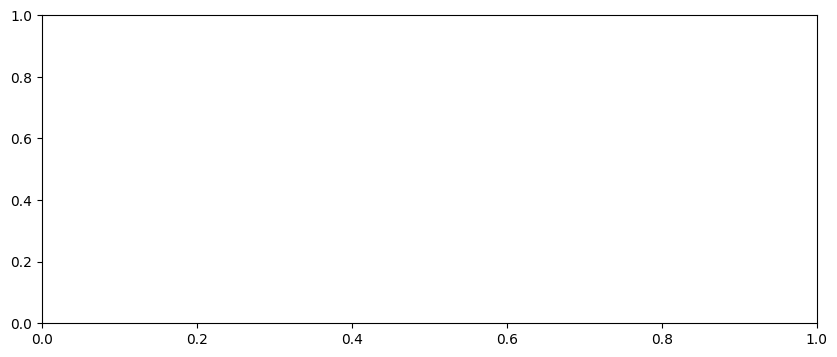

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
# -------------------------------
# PARAMETERS
# -------------------------------
sf = sf
bw = bw
fs = fs
input_row = input_row
input_col = input_col

snr = -15
seed = 591

plt.ion()  # interactive mode ON
fig, ax = plt.subplots(figsize=(10, 4))

# -------------------------------
# LOOP OVER SYMBOLS
# -------------------------------
active = False
if active:
        
    for symbol in range(0, 512):
        clear_output(wait=True)
        # 1. Generate clean symbol
        x1 = lora_init.gen_symbol_fs(symbol, sf=sf, bw=bw, Fs=fs)

        # 2. Add noise (fixed seed for reproducibility)
        x = lora_init.awgn_iq_with_seed(x1, snr, seed)

        # 3. Spectrogram
        input_spec = create_spectrogram_from_torch(
            x, sf, bw, fs,
            input_row, input_col,
            0, 0, 1, None
        )

        # 4. Flatten before compress
        flat = input_spec.flatten().reshape(1, -1)

        # 5. Compress
        out = multi_bam.compress(flat)
        a = out.squeeze()

        # -------------------------------
        # PLOTTING (movie style)
        # -------------------------------
        plt.figure(figsize=(10,4))
        plt.bar(np.arange(len(a)), a)
        plt.ylim(-15, 15)
        plt.yticks(np.arange(-15, 15, 1)) 
        plt.title(f"Compressed Representation | Symbol = {symbol}")
        plt.xlabel("Latent Dimension")
        plt.ylabel("Value")
        plt.show()

    plt.ioff()  # interactive mode OFF
